# Lesson 174 · Fine-tuning protocol

**One skill:** implement and defend the parameter-update boundary. The narrative contains saved author evidence. Executable cells below perform a separate fresh adapter/seed 0 fit. Full paper reproduction NOT_RUN; this is retrospective F1 autocomplete.

**One win:** choose which parameters may change, prove your optimizer obeys that choice, and assess whether a pretrained start actually helps. About 20 minutes; run the lab separately.

[171: choose the corpus](https://avistian.github.io/relational/lessons/0171-corpus-of-databases.html) → [172: encode cells](https://avistian.github.io/relational/lessons/0172-schema-tokenization.html) → [173: pretrain](https://avistian.github.io/relational/lessons/0173-multi-task-pretraining.html) → **174: adapt and compare**.

Recall: why are target masking and training-only preprocessing separate requirements? What did the L173 constant baseline reveal?

## 1 · A checkpoint is a starting point, not a promise

Lesson 173 trained one encoder across 21 masked-cell tasks. Every trained run had worse aggregate test loss than its constant baseline. We therefore begin with an open question: **when later labels arrive, does preserving this representation help, constrain, or hinder learning?** Fine-tuning means updating a pretrained model using an adaptation objective. Its successful execution is not evidence that pretraining was useful.

Our model predicts a hidden field from up to four same-row cells and four dated foreign-key-parent cells. Other fields can describe an already completed race. We continue this **autocomplete** task; we do not turn it into future-race forecasting by calling the later years “test.” The target identity stays absent from every context path.

## 2 · Draw the update boundary before creating the optimizer

A representation `h` is the 32-wide output of the shared encoder. A task-specific head converts it to one numeric prediction or a vector of category logits. Different adaptation policies permit different changes:

| Arm | Encoder | Residual adapter | Original heads | Initialization |
|---|---|---|---|---|
| Freeze | Fixed | Absent | Train | Pretrained |
| Full | Train | Absent | Train | Pretrained |
| Adapter | Fixed | Train | Train | Pretrained + identity adapter |
| Scratch | Train | Absent | Train | Random |

“Freeze” here means head-only tuning: it is not zero-gradient inference. “Full” means all parameters may receive updates, not that every tensor necessarily changes on every batch. We retain the original heads because these are the **same tasks**. A new task would require a compatible new output head and a separate initialization policy.

<figure tabindex="0" style="overflow-x:auto">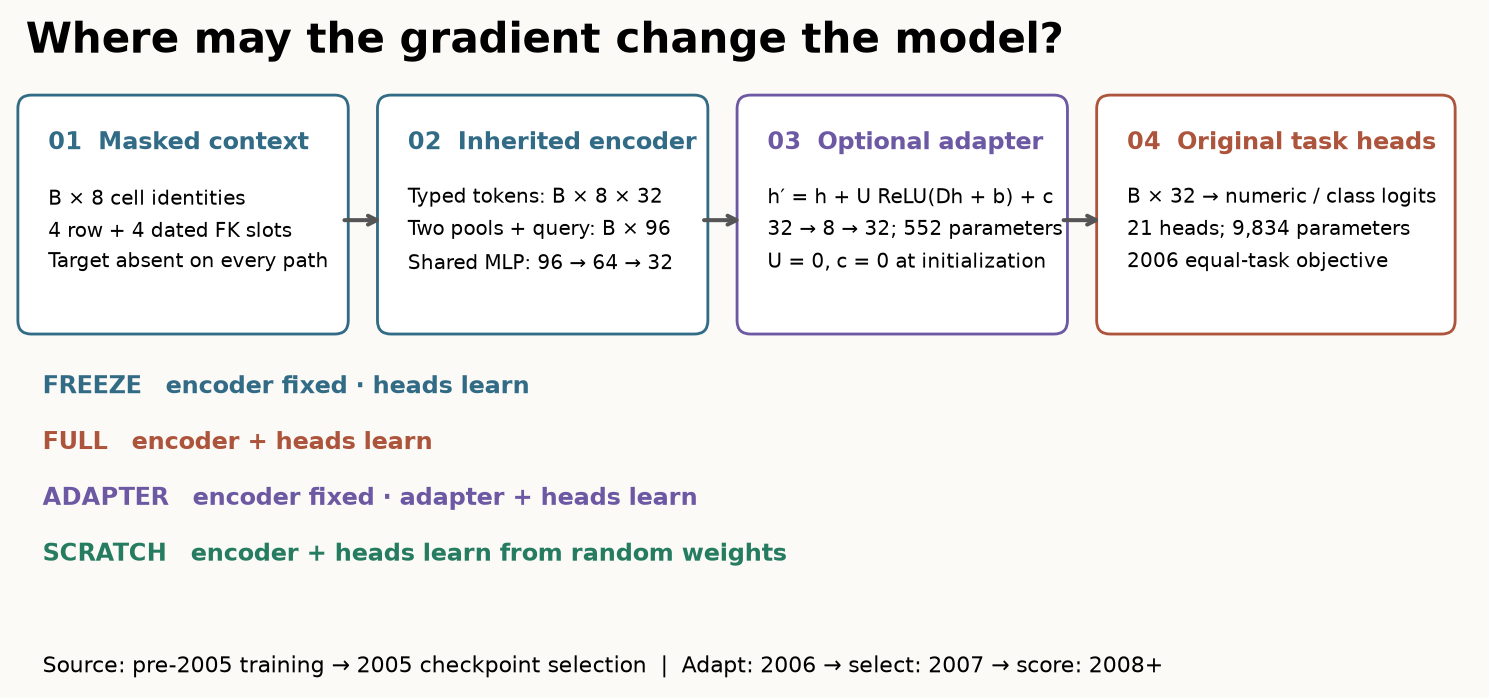<figcaption>Actual L174 computation and update boundaries. The optional 32→8→32 residual adapter sits between the shared encoder and the original task heads. Scroll horizontally on narrow screens.</figcaption></figure>

The original encoder has **18,592 parameters**, and the 21 heads have **9,834**. The architecture remains L173's typed token embeddings, separate row/FK means, a query-column embedding, and a 96→64→32 shared MLP. The adapter adds 552 parameters after that MLP. An optimizer only receives parameters with `requires_grad=True`; the audit also compares every frozen tensor byte for byte at every saved epoch.

```python
for name, parameter in model.named_parameters():
    parameter.requires_grad_(
        arm in {"full", "scratch"}
        or name.startswith("heads.")
        or (arm == "adapter" and name.startswith("adapter."))
    )
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=0.001
)
```

Setting `model.eval()` does **not** freeze parameters. It changes behaviors such as dropout and batch normalization; this model has neither. Conversely, a frozen encoder must still perform a forward pass. Parameter savings do not automatically imply proportional runtime savings.

Intervene on the update policy: freeze trains9,834 parameters; full 28,426; adapter 10,386; scratch 28,426. Which tensors stay byte-identical?

<figure tabindex="0" style="overflow-x:auto">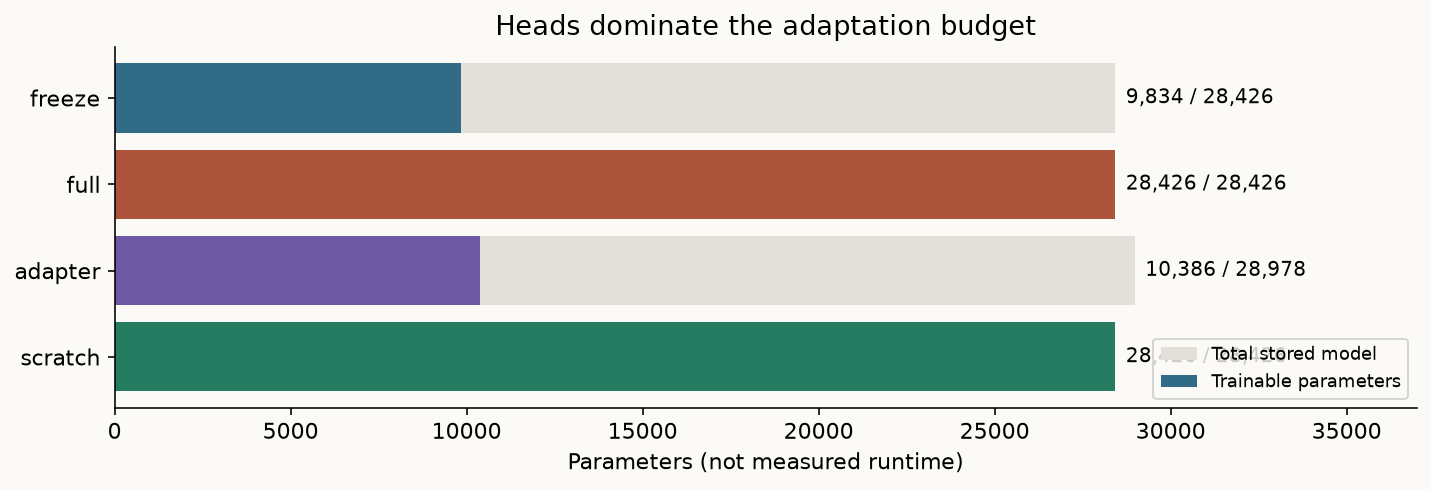<figcaption>Trainable and total parameters for the actual course model. Existing heads dominate the adapter arm; parameter count is not a runtime measurement. Scroll horizontally on narrow screens.</figcaption></figure>

## 3 · An identity adapter can start learning

> **In plain terms.** An adapter learns a correction to the existing representation. Start with a zero correction so the initial predictions stay unchanged, then let training decide what to add.

**Read the symbols.** ReLU keeps positive values and replaces negative values with zero. D and U are learned matrices that narrow and then widen the vector; b and c are learned offsets. A gradient measures how a small parameter change affects the loss. Backpropagation computes these derivatives through the model using the chain rule. The upstream gradient below is the loss derivative arriving at the adapter's output.

The residual path is `h′ = h + U ReLU(Dh + b) + c`. Here D maps 32→8 and U maps 8→32. Its count is `(32×8 + 8) + (8×32 + 32) = 552`. Initialize D randomly and set U and c to zero. Then `h′ = h` exactly before any update, so the adapter arm starts with the same predictions as the frozen/full pretrained arms.

For a two-dimensional worked trace, let `h = [2, −1]`, `D = [1, 0]`, and both biases and U be zero. The bottleneck activation is 2; the initial output is still `[2, −1]`. If the upstream gradient is `[1, −1]`, the gradient of U is `[2, −2]`, while the gradient of D is zero because its chain rule contains U. After U updates, D can receive gradients too. Setting **both** projections to zero would obstruct learning of the residual weights under ReLU.

Predict: with a zero up projection, which adapter projection can receive a nonzero weight gradient on the first step? Work through the chain rule before reading the answer.

[Houlsby et al., ICML 2019](https://proceedings.mlr.press/v97/houlsby19a.html) is the primary reading for adapting a fixed pretrained network with small added modules. Their BERT placement and NLP benchmark results are not reproduced by our single adapter after a pooled relational MLP. This is also not LoRA: we add a nonlinear residual module rather than a low-rank update to an existing weight matrix.

## 4 · Freeze the data and comparison too

**Named experiment: L174 F1 Temporal Adaptation.** Use all 21 tasks and the complete eligible population, with no row subsampling. Keep L173's pre-2005 normalization, vocabulary, capped context and target-erasure rules. Categories unseen in that vocabulary remain UNKNOWN, including during adaptation; we do not rebuild embeddings using later labels.

| Role | Period | Target cells | Permitted use |
|---|---|---:|---|
| Source training | Before 2005 | 244,410 | Original encoder/head fitting |
| Source validation | 2005 | 6,354 | Choose source checkpoint |
| Adaptation training | 2006 | 6,429 | Gradient updates and task counts |
| Adaptation validation | 2007 | 6,074 | Select adaptation epoch |
| Adaptation test | 2008 onward | 106,757 | Score selected models |

For seeds 0, 1 and 2, load the corresponding **cell-weighted** source checkpoint, chosen on 2005 validation. This source arm is fixed; we do not choose between L173 loss-weighting arms using their test scores. Each of four adaptation arms runs ten complete epochs, batch 1,024, Adam at 0.001, no weight decay, and equal-task weights `N / (21 × N_task)` computed only from 2006. Each seed uses identical minibatch permutations across arms. With seven batches per epoch, every fit makes 70 optimizer updates.

Select the earliest minimum 2007 validation macro loss. Score its entire test population afterward. Save all 120 epoch checkpoints, original states and full keyed predictions. This is a fixed-schedule comparison; a shared learning rate and update count do not establish equally tuned optima or equal compute. Seeds describe initialization/order variation, not three independent databases.

**Prior exposure matters:** L173 already evaluated 2006 onward, and these tasks were included in pretraining. The new split creates a useful retrospective adaptation exercise. It does not restore a pristine unseen test, establish new-task transfer, or prove historical feature availability. Event-time checks cannot recover absent ingestion histories.

## 5 · Read the control arms before declaring success

**Measured: all twelve fits complete.** Lower macro task loss is better; every entry uses all 106,757 test targets.

| Arm | Seed 0 | Seed 1 | Seed 2 | Mean ± sample SD |
|---|---:|---:|---:|---:|
| freeze | 1.232717 | 1.251662 | 1.260463 | 1.248281 ± 0.014178 |
| full | 1.236253 | 1.238285 | 1.268198 | 1.247579 ± 0.017886 |
| adapter | 1.222419 | 1.244116 | 1.254079 | 1.240205 ± 0.016188 |
| scratch | 1.160042 | 1.163677 | 1.150535 | 1.158085 ± 0.006786 |
| Unchanged source | 1.416096 | 1.405385 | 1.420837 | 1.414106 ± 0.007916 |

2006 training-only constant baseline: **1.175455**. Parameter counts: freeze 9,834; full 28,426; adapter 10,386 (including 552 new); scratch 28,426.

<figure tabindex="0" style="overflow-x:auto">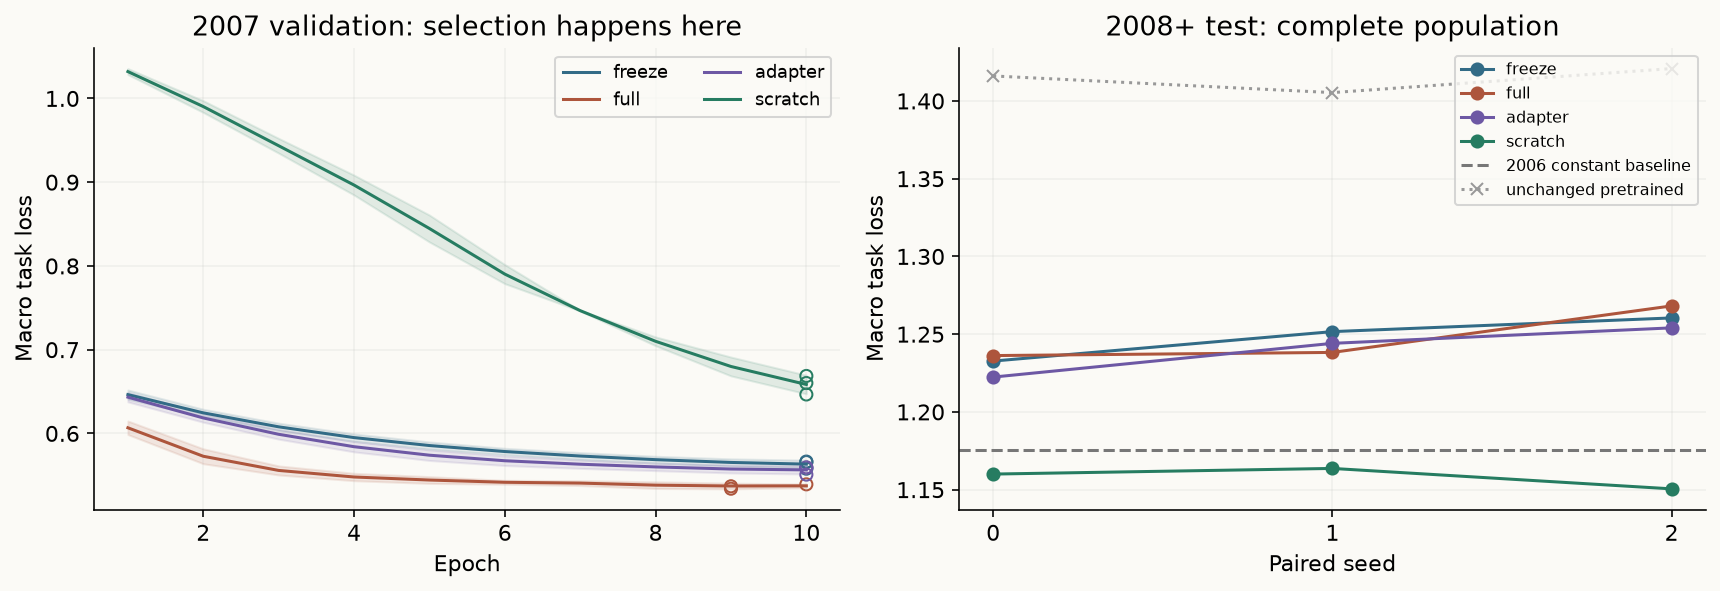<figcaption>Measured three-seed validation curves (mean ± sample SD) and complete test losses. Open circles mark selected epochs. The test control includes unchanged checkpoints and a 2006 constant baseline. Scroll horizontally on narrow screens.</figcaption></figure>

**Measured conclusion:** scratch has lower test macro loss than every pretrained adaptation arm for each of the three seeds. All pretrained adaptation arms improve on their unchanged source checkpoints, yet remain worse than the constant baseline. These runs do not establish a benefit from pretraining. Adapter minus freeze averages -0.008076, with paired differences -0.010298, -0.007546, -0.006384. Scratch minus full averages -0.089494. This is a descriptive result for this exposed F1 population and fixed schedule, not a universal ranking of adaptation methods.

The **unchanged checkpoint** measures improvement over doing nothing. The **scratch arm** asks whether pretraining helps under this fixed adaptation schedule. The **constant baseline** predicts a numerical 2006 training mean or Laplace-smoothed category frequencies. It checks whether a learned solution adds value over a very simple adaptation rule.

Macro task loss averages Huber on pretraining-normalized numeric targets and categorical cross-entropy. It is a declared objective, not one common physical unit. Read all 21 task losses and the separate raw-unit MAE or accuracy before generalizing. [Per-task validation curves](https://avistian.github.io/relational/labs/figures/l174/per-task-curves.svg) and [the full measured report](https://avistian.github.io/relational/labs/evidence/l174/runs/report.md) expose reversals and heterogeneous behavior.

[Relational Transformer v1, §4.2 and Appendix D](https://arxiv.org/html/2510.06377v1#S4.SS2) compares pretrained and untrained relational models on downstream tasks. Our corpus, architecture, task exposure, schedule and metrics differ. The paper reports about 1.5 hours on eight A100 GPUs per fine-tuning run: roughly 12 GPU-hours. At [the pricing snapshot](https://modal.com/pricing), that is approximately $25–30 GPU-only, exceeding the course's $10 total ceiling before other costs. **Whole-paper reproduction: NOT_RUN.**

## 6 · Implement, check, defend

[Student notebook](https://avistian.github.io/relational/labs/0174-fine-tuning-protocol.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0174-fine-tuning-protocol.html) · [Quick reference](https://avistian.github.io/relational/reference/fine-tuning-protocol.html) · [Frozen reproduction protocol](https://avistian.github.io/relational/labs/l174-reproduction.md).

The portable notebook shows the actual encoder, adapter and trainer. Implement three live functions: the trainability policy, temporal split, and earliest-validation selection. CHECK cells reject plausible wrong answers. A fresh full adapter/seed-0 fit calls your functions; a separate gate reruns all twelve fits. The displayed author comparison is saved evidence until you run those cells yourself.

**Exercise:** before running, predict which tensors change on the first and second adapter steps. Then verify the frozen encoder, inspect the selected epoch, and compare your test loss against scratch and constant controls. Explain why the 552 new parameters do not mean only 552 parameters are trained.

**Reproduction budget:** $0 cloud/API, 3,600 aggregate numerical seconds for preparation, failures, twelve fits, verification and the fresh notebook check. A timeout leaves `INCOMPLETE`; no hidden smaller substitute. Original pretraining is reused. Browser checks, live Colab, deployment and learner mastery remain separate evidence claims.

Write your defense before consulting teacher feedback.

**Exit:** submit a 200–400-word defense identifying the update boundary, adapter initialization, checkpoint-selection boundary, strongest warranted result, and prior-exposure limitation. Learner status remains **PENDING_WRITTEN_DEFENSE**. Ask the teaching agent about any unclear step; bring your own trace or failed CHECK so we can diagnose it together.


## PROVIDED · Runtime and visible code
Requires NumPy, PyTorch and matplotlib. The author runtime is recorded below. No cloud service, account or network is needed after downloading the notebook. Model definitions are inlined; no hidden package imports implement the experiment.

In [ ]:
# @colab-bootstrap
import os
os.environ.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1")
import hashlib,json,time,tempfile,base64,io,zipfile
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
print("Author versions: numpy 2.5.0, torch 2.13.0+cpu; other versions may differ numerically.")

## PROVIDED · task_weights

Visible support code used by the complete experiment.

In [ ]:
def task_weights(tasks, counts, arm):
    """Importance weights use the entire training population, not batch counts."""
    if arm not in {'cell','task'} or counts.ndim!=1 or not torch.isfinite(counts).all() or (counts<=0).any():
        raise ValueError('Positive finite training counts and cell/task arm required')
    if arm=='cell':return torch.ones_like(tasks,dtype=torch.float32)
    return counts.sum()/(len(counts)*counts[tasks])

## TODO · Select without test access

Return the zero-based earliest finite validation minimum. Reject an empty list or any nonfinite value. Test scores must never enter this function.

In [ ]:
def select_epoch(validation):
    raise NotImplementedError("TODO: select_epoch")

## PROVIDED · MaskedCellModel

Inherited encoder: typed tokens, separate row/FK pools, shared MLP and local heads.

In [ ]:
class MaskedCellModel(nn.Module):
    """32-d tokens, separate row/parent pools, shared MLP, task-specific heads."""
    def __init__(self, tasks):
        super().__init__();self.tasks=tasks
        self.column=nn.Embedding(len(tasks)+1,32,padding_idx=0)
        self.category=nn.Embedding(1+sum(t['classes'] for t in tasks),32,padding_idx=0)
        self.numeric=nn.Linear(1,32,bias=False)
        self.shared=nn.Sequential(nn.Linear(96,64),nn.ReLU(),nn.Linear(64,32),nn.ReLU())
        self.heads=nn.ModuleList(nn.Linear(32,t['classes'] if t['kind']=='category' else 1) for t in tasks)
        self.max_classes=max(t['classes'] for t in tasks)

    def forward(self, context, task, columns, numeric, categories):
        present=(context!=0).unsqueeze(-1)
        tokens=self.column(columns[context])+self.category(categories[context])+self.numeric(numeric[context,None])
        tokens=tokens*present
        row=tokens[:,:4].sum(1)/present[:,:4].sum(1).clamp(min=1)
        parent=tokens[:,4:].sum(1)/present[:,4:].sum(1).clamp(min=1)
        hidden=self.shared(torch.cat([row,parent,self.column(task+1)],dim=1))
        output=hidden.new_zeros((len(task),self.max_classes))
        for i,head in enumerate(self.heads):
            selected=task==i
            if selected.any():output[selected,:head.out_features]=head(hidden[selected])
        return output

## PROVIDED · cell_losses

Visible support code used by the complete experiment.

In [ ]:
def cell_losses(output, task, target, tasks):
    losses=output.new_zeros(len(task))
    for i,spec in enumerate(tasks):
        selected=task==i
        if not selected.any():continue
        if spec['kind']=='number':
            losses[selected]=F.huber_loss(output[selected,0],target[selected],reduction='none',delta=1.)
        else:
            losses[selected]=F.cross_entropy(output[selected,:spec['classes']],target[selected].long(),reduction='none')
    return losses

## PROVIDED · tensor_packet

Visible support code used by the complete experiment.

In [ ]:
def tensor_packet(arrays):
    return {k:torch.from_numpy(v.copy()) for k,v in arrays.items() if k in {'context','task','target','split','columns','numeric','categories','cell_ids'}}

## PROVIDED · predict

Visible support code used by the complete experiment.

In [ ]:
def predict(model, data, indices, batch_size=1024):
    model.eval();outputs=[]
    with torch.no_grad():
        for ix in torch.as_tensor(indices,dtype=torch.long).split(batch_size):
            outputs.append(model(data['context'][ix],data['task'][ix],data['columns'],data['numeric'],data['categories']).numpy())
    return np.concatenate(outputs)

## PROVIDED · score_outputs

Visible support code used by the complete experiment.

In [ ]:
def score_outputs(outputs, targets, task_ids, tasks):
    losses=cell_losses(torch.as_tensor(outputs),torch.as_tensor(task_ids),torch.as_tensor(targets),tasks).numpy()
    per_task=[]
    for i,spec in enumerate(tasks):
        mask=task_ids==i
        if not mask.any():raise ValueError('No evaluation targets for '+spec['name'])
        row=dict(task=spec['name'],count=int(mask.sum()),loss=float(losses[mask].astype(float).mean()))
        if spec['kind']=='number':row['mae_raw']=float(np.abs(outputs[mask,0]-targets[mask]).mean()*spec['scale'])
        else:
            row['accuracy']=float((outputs[mask,:spec['classes']].argmax(1)==targets[mask]).mean())
            row['unknown_targets']=int((targets[mask]==0).sum())
        per_task.append(row)
    return dict(macro_loss=float(np.mean([x['loss'] for x in per_task])),cell_loss=float(losses.astype(float).mean()),tasks=per_task)

## TODO · Separate adaptation, selection and evaluation

Input UTC seconds for each target identity. Return -1 before2006,0 during2006,1 during2007,2 from2008 onward. Do not index the padded date lookup as though it were the target array.

In [ ]:
def adaptation_split(dates):
    raise NotImplementedError("TODO: adaptation_split")

## TODO · Set the update boundary

Validate the arm (freeze/full/adapter/scratch). Set every parameter’s requires_grad flag: all original parameters for full/scratch; only heads for freeze; heads and adapter for adapter. The optimizer will use this live policy.

In [ ]:
def configure_trainable(model,arm):
    raise NotImplementedError("TODO: configure_trainable")

## PROVIDED · ResidualAdapter

The actual residual 32→8→32 module. Trace the zero up projection before training.

In [ ]:
class ResidualAdapter(nn.Module):
    """Zero up projection makes x + up(ReLU(down(x))) initially identical to x."""
    def __init__(self):
        super().__init__();self.down=nn.Linear(32,8);self.up=nn.Linear(8,32)
        nn.init.zeros_(self.up.weight);nn.init.zeros_(self.up.bias)
    def forward(self,x):return x+self.up(F.relu(self.down(x)))

## PROVIDED · AdaptationModel

Same computation as L173 with the optional adapter immediately before the original heads.

In [ ]:
class AdaptationModel(MaskedCellModel):
    """Same L173 encoder and original heads; optional adapter before heads."""
    def __init__(self,tasks,arm):
        super().__init__(tasks)
        self.adapter=ResidualAdapter() if arm=='adapter' else nn.Identity()

    def forward(self,context,task,columns,numeric,categories):
        present=(context!=0).unsqueeze(-1)
        tokens=self.column(columns[context])+self.category(categories[context])+self.numeric(numeric[context,None])
        tokens=tokens*present
        row=tokens[:,:4].sum(1)/present[:,:4].sum(1).clamp(min=1)
        parent=tokens[:,4:].sum(1)/present[:,4:].sum(1).clamp(min=1)
        hidden=self.adapter(self.shared(torch.cat([row,parent,self.column(task+1)],dim=1)))
        output=hidden.new_zeros((len(task),self.max_classes))
        for i,head in enumerate(self.heads):
            selected=task==i
            if selected.any():output[selected,:head.out_features]=head(hidden[selected])
        return output

## PROVIDED · state_hash

Visible support code used by the complete experiment.

In [ ]:
def state_hash(state):
    h=hashlib.sha256()
    for name,value in sorted(state.items()):
        h.update(name.encode());h.update(str(value.dtype).encode());h.update(str(tuple(value.shape)).encode());h.update(value.detach().cpu().numpy().tobytes())
    return h.hexdigest()

## PROVIDED · train_adaptation

The actual ten-epoch trainer. It calls your live policy, splitter and selector; saves every epoch and refuses existing output directories.

In [ ]:
def train_adaptation(arrays,tasks,source_state,arm,seed,destination,policy=configure_trainable,split_fn=adaptation_split,select_fn=select_epoch):
    """Ten full passes of 2006; 2007 selects; 2008+ is scored only afterward."""
    destination=Path(destination);destination.mkdir(parents=True,exist_ok=False)
    start=time.monotonic();torch.set_num_threads(1);torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    split=split_fn(arrays['dates'][arrays['cell_ids']])
    train,valid,test=[np.flatnonzero(split==i) for i in range(3)]
    counts=torch.from_numpy(np.bincount(arrays['task'][train],minlength=len(tasks))).float()
    if min(len(train),len(valid),len(test))==0 or (counts<=0).any():raise ValueError('Missing adaptation population')
    model=AdaptationModel(tasks,arm)
    if arm!='scratch':
        missing,unexpected=model.load_state_dict(source_state,strict=False)
        assert not unexpected and set(missing)==({k for k in model.state_dict() if k.startswith('adapter.')} if arm=='adapter' else set())
    policy(model,arm)
    initial={k:v.detach().clone() for k,v in model.state_dict().items()}
    torch.save(initial,destination/'initial.pt')
    trainable=[name for name,p in model.named_parameters() if p.requires_grad]
    optimizer=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],lr=.001,weight_decay=0)
    data=tensor_packet(arrays);rng=np.random.default_rng(seed);history=[];permutations=[]
    for epoch in range(10):
        model.train();order=rng.permutation(train);permutations.append(hashlib.sha256(order.tobytes()).hexdigest())
        weighted=0.;seen=np.zeros(len(tasks),dtype=np.int64)
        for ix in torch.as_tensor(order).split(1024):
            optimizer.zero_grad(set_to_none=True)
            out=model(data['context'][ix],data['task'][ix],data['columns'],data['numeric'],data['categories'])
            losses=cell_losses(out,data['task'][ix],data['target'][ix],tasks)
            loss=(losses*task_weights(data['task'][ix],counts,'task')).mean()
            if not torch.isfinite(loss):raise ValueError('Nonfinite loss')
            loss.backward();optimizer.step();weighted+=float(loss.detach())*len(ix)
            seen+=np.bincount(arrays['task'][ix],minlength=len(tasks))
        validation=score_outputs(predict(model,data,valid),arrays['target'][valid],arrays['task'][valid],tasks)
        history.append(dict(epoch=epoch+1,training_objective=weighted/len(train),training_counts=seen.tolist(),validation=validation))
        torch.save(model.state_dict(),destination/f'epoch-{epoch+1}.pt')
    selected=select_fn([e['validation']['macro_loss'] for e in history])+1
    model.load_state_dict(torch.load(destination/f'epoch-{selected}.pt',weights_only=True))
    output=predict(model,data,test)
    np.savez_compressed(destination/'test.npz',cell_ids=arrays['cell_ids'][test],task=arrays['task'][test],target=arrays['target'][test],output=output)
    changed=[k for k,v in model.state_dict().items() if not torch.equal(v,initial[k])]
    result=dict(arm=arm,seed=seed,source_sha256=state_hash(source_state) if arm!='scratch' else None,initial_sha256=state_hash(initial),initial_backbone_sha256=state_hash({k:v for k,v in initial.items() if not k.startswith(('heads.','adapter.'))}),trainable_names=trainable,trainable_parameters=sum(p.numel() for p in model.parameters() if p.requires_grad),total_parameters=sum(p.numel() for p in model.parameters()),selected_epoch=selected,selected_sha256=state_hash(model.state_dict()),changed_names=changed,permutation_sha256=permutations,epochs=history,test=score_outputs(output,arrays['target'][test],arrays['task'][test],tasks),seconds=time.monotonic()-start)
    (destination/'result.json').write_text(json.dumps(result,indent=2)+'\n')
    print(f'{arm} seed{seed}: epoch{selected}, test macro {result["test"]["macro_loss"]:.6f}',flush=True)
    return result

## PROVIDED · load_adaptation_packet

Visible support code used by the complete experiment.

In [ ]:
def load_adaptation_packet(directory):
    """Authenticate every dependency before any output or training is created."""
    directory=Path(directory);manifest=json.loads((directory/'manifest.json').read_text())
    for name,digest in manifest['files'].items():
        if hashlib.sha256((directory/name).read_bytes()).hexdigest()!=digest:raise ValueError('Input hash mismatch: '+name)
    arrays=dict(np.load(directory/'population.npz',allow_pickle=False))
    tasks=json.loads((directory/'tasks.json').read_text())
    states=[torch.load(directory/f'source-{seed}.pt',weights_only=True) for seed in range(3)]
    return arrays,tasks,states,manifest

## PROVIDED · check174

Behavioral checks perturb trainability, exercise actual optimizer updates and test the temporal boundary.

In [ ]:
def check174(policy, split_fn, select_fn, model_cls):
    tasks=[dict(classes=1,kind='number'),dict(classes=3,kind='category')]
    for arm in ['freeze','full','adapter','scratch']:
        torch.manual_seed(5);model=model_cls(tasks,arm)
        policy(model,arm)
        before={k:v.clone() for k,v in model.state_dict().items()}
        opt=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],lr=.01)
        context=torch.tensor([[1,2,0,0,0,0,0,0],[2,1,0,0,0,0,0,0]])
        columns=torch.tensor([0,1,2]);numeric=torch.tensor([0.,2.,-1.]);categories=torch.tensor([0,0,1])
        for _ in range(3):
            out=model(context,torch.tensor([0,1]),columns,numeric,categories)
            loss=(out[:,0]-3).square().sum();opt.zero_grad();loss.backward();opt.step()
        changed={k for k,v in model.state_dict().items() if not torch.equal(v,before[k])}
        assert any(k.startswith('heads.') for k in changed)
        if arm in ['freeze','adapter']:
            assert not any(not k.startswith(('heads.','adapter.')) for k in changed),'Frozen backbone changed'
            assert all(not p.requires_grad for k,p in model.named_parameters() if not k.startswith(('heads.','adapter.')))
        else:assert any(k.startswith('shared.') for k in changed),'Full training did not update encoder'
        if arm=='adapter':assert any(k.startswith('adapter.') for k in changed),'Adapter cannot learn'
    torch.manual_seed(2);plain=model_cls(tasks,'freeze')
    torch.manual_seed(2);adapt=model_cls(tasks,'adapter')
    x=torch.randn(7,32);assert torch.equal(adapt.adapter(x),x),'Adapter must start at identity'
    assert torch.equal(plain(context,torch.tensor([0,1]),columns,numeric,categories),adapt(context,torch.tensor([0,1]),columns,numeric,categories))
    dates=np.array(['2005-12-31','2006-01-01','2006-12-31','2007-01-01','2007-12-31','2008-01-01'],dtype='datetime64[s]').astype('int64')
    assert np.array_equal(split_fn(dates),[-1,0,0,1,1,2])
    assert select_fn([.4,.2,.2])==1
    for invalid in [[],[np.nan],[np.inf]]:
        try:select_fn(invalid)
        except ValueError:pass
        else:raise AssertionError('Invalid validation scores accepted')
    try:policy(plain,'typo')
    except ValueError:pass
    else:raise AssertionError('Unknown arm accepted')
    return 'PASS'

## CHECK · Exercise your live functions
The tests perform actual updates, require an identity adapter, check frozen weights and test exact year boundaries and selection ties.

In [ ]:
assert check174(configure_trainable,adaptation_split,select_epoch,AdaptationModel)=="PASS"
print("CHECK: update policy, adapter learning, split and selection PASS")

## PROVIDED · Authenticated portable packet
All 370,024 original targets and their permitted contexts, inherited preprocessing and three selected source checkpoints. Fresh adaptation uses the full 6,429/6,074/106,757 split. Hashes detect corruption; the repository verifier independently reconstructs the population from original tables. Hashes alone do not prove historical availability.

In [ ]:
encoded='...'
raw=base64.b64decode(encoded)
assert hashlib.sha256(raw).hexdigest()=='24bb1f8975d3d91a17430013ab483d2c42683752bebd5966f21a730a786896bd'
ROOT=Path(tempfile.mkdtemp(prefix="l174-portable-"))
with zipfile.ZipFile(io.BytesIO(raw)) as z:
 for name in z.namelist():
  assert not Path(name).is_absolute() and ".." not in Path(name).parts
 z.extractall(ROOT)
arrays,tasks,states,manifest=load_adaptation_packet(ROOT)
split=adaptation_split(arrays["dates"][arrays["cell_ids"]])
assert [int((split==i).sum()) for i in range(3)]==[6429,6074,106757]
assert not (arrays["context"]==arrays["cell_ids"][:,None]).any()
print("Complete population and actual source checkpoints authenticated")

## RUN · One fresh complete adaptation fit
Adapter/seed0, ten full epochs, no subsampling. This is a fresh run from the inherited source checkpoint, not replay of the twelve author fits. The live TODO functions are passed into the trainer.

In [ ]:
RUN=Path(tempfile.mkdtemp(prefix="l174-fresh-"))/"adapter-0"
fresh=train_adaptation(arrays,tasks,states[0],"adapter",0,RUN,policy=configure_trainable,split_fn=adaptation_split,select_fn=select_epoch)
Path("l174-fresh-report.json").write_text(json.dumps(fresh,indent=2)+"\n")
print("Fresh selected epoch:",fresh["selected_epoch"],"test macro:",fresh["test"]["macro_loss"])

## CHECK · Compare fresh execution with saved author evidence
Timing is deliberately excluded from equality. On other library versions, investigate score differences rather than replacing the author reference.

In [ ]:
expected={'arm': 'adapter', 'seed': 0, 'source_sha256': '6dca06bd96a7485e0417b15ddc50255e116f92eefb6cf3c0e520f41203d9d6b5', 'initial_sha256': 'dff52f259373bf189c4848903f510904103c6ae50c639a8a816ad8c020b81a95', 'initial_backbone_sha256': '9b76993fba68eb65cb862acc63ac907185f7b7ddd2cab37c0e6677a2ca47617f', 'trainable_names': ['heads.0.weight', 'heads.0.bias', 'heads.1.weight', 'heads.1.bias', 'heads.2.weight', 'heads.2.bias', 'heads.3.weight', 'heads.3.bias', 'heads.4.weight', 'heads.4.bias', 'heads.5.weight', 'heads.5.bias', 'heads.6.weight', 'heads.6.bias', 'heads.7.weight', 'heads.7.bias', 'heads.8.weight', 'heads.8.bias', 'heads.9.weight', 'heads.9.bias', 'heads.10.weight', 'heads.10.bias', 'heads.11.weight', 'heads.11.bias', 'heads.12.weight', 'heads.12.bias', 'heads.13.weight', 'heads.13.bias', 'heads.14.weight', 'heads.14.bias', 'heads.15.weight', 'heads.15.bias', 'heads.16.weight', 'heads.16.bias', 'heads.17.weight', 'heads.17.bias', 'heads.18.weight', 'heads.18.bias', 'heads.19.weight', 'heads.19.bias', 'heads.20.weight', 'heads.20.bias', 'adapter.down.weight', 'adapter.down.bias', 'adapter.up.weight', 'adapter.up.bias'], 'trainable_parameters': 10386, 'total_parameters': 28978, 'selected_epoch': 10, 'selected_sha256': '06d91882f0e43f9970ede03065fc1994db6edb5637a0768cda232af6c16869d1', 'changed_names': ['heads.0.weight', 'heads.0.bias', 'heads.1.weight', 'heads.1.bias', 'heads.2.weight', 'heads.2.bias', 'heads.3.weight', 'heads.3.bias', 'heads.4.weight', 'heads.4.bias', 'heads.5.weight', 'heads.5.bias', 'heads.6.weight', 'heads.6.bias', 'heads.7.weight', 'heads.7.bias', 'heads.8.weight', 'heads.8.bias', 'heads.9.weight', 'heads.9.bias', 'heads.10.weight', 'heads.10.bias', 'heads.11.weight', 'heads.11.bias', 'heads.12.weight', 'heads.12.bias', 'heads.13.weight', 'heads.13.bias', 'heads.14.weight', 'heads.14.bias', 'heads.15.weight', 'heads.15.bias', 'heads.16.weight', 'heads.16.bias', 'heads.17.weight', 'heads.17.bias', 'heads.18.weight', 'heads.18.bias', 'heads.19.weight', 'heads.19.bias', 'heads.20.weight', 'heads.20.bias', 'adapter.down.weight', 'adapter.down.bias', 'adapter.up.weight', 'adapter.up.bias'], 'permutation_sha256': ['bedc52d9659239e3e2d70b138c7e56dc0022f0cc00b33218b606aa54b5a0c4a4', '51bdc83b58723b2b2c96698ca4a11e103e929530e84ace322f200e3b52aa4dc0', '521500fc42cd76f195a585c75278918f9ee16c4928917a08d4d187bacb2b0edc', '8e98b28347670eef5715eb08b79eb8cef5c48c2a2f97d13a6a17557bffc1d338', '3f285a04f55593d0f0608e5b793c29a3549ff0630f256fe98237ef49361f9fa7', 'bc337cffc5014ac7648be60b0976f45e3182702ecfd503858b6bae9a4b500534', '8dbd2fa73330714745ffc26c980ca3e12580cb907a984f25e6a942b47718ef31', '369280ff14040f9c632503f9cba2edf4ed4b9951cbe9e3e2e262aa4d5e6d8f62', '0271d658c6704e81112bfe66c684c95bf717e0b62526b0a4a67f7b92321c6ac4', '85825a2464f8b9987a38b867e0b4371ac21b334b93e827d7b64381f60675c055'], 'epochs': [{'epoch': 1, 'training_objective': 0.6602614581501489, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.6498058417765913, 'cell_loss': 0.6940186054350231, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6826476409675225, 'mae_raw': 3.557346820831299}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.35835537874048956, 'mae_raw': 18.397193908691406}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.2947955928781123, 'mae_raw': 2.9214913845062256}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.3955279393586792, 'mae_raw': 0.8438137173652649}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.9638308334478083, 'accuracy': 0.13101604278074866, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.27522808853013814, 'mae_raw': 4.230034351348877}, {'task': 'races.round', 'count': 17, 'loss': 0.5469470729722696, 'mae_raw': 4.267111301422119}, {'task': 'races.year', 'count': 17, 'loss': 0.9044918295215157, 'mae_raw': 21.066192626953125}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.3585581817850602, 'mae_raw': 13.182341575622559}, {'task': 'results.grid', 'count': 374, 'loss': 0.21171607508295176, 'mae_raw': 4.053243637084961}, {'task': 'results.laps', 'count': 374, 'loss': 0.11706794241316393, 'mae_raw': 12.126809120178223}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.08090587566621994, 'mae_raw': 559550.125}, {'task': 'results.number', 'count': 374, 'loss': 3.1609889833047426, 'accuracy': 0.09090909090909091, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.31065112824353736, 'mae_raw': 1.3333982229232788}, {'task': 'results.position', 'count': 281, 'loss': 0.28656572926242363, 'mae_raw': 2.684948444366455}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.09665165451246926, 'mae_raw': 2.938938856124878}, {'task': 'results.rank', 'count': 360, 'loss': 0.2830506698198361, 'mae_raw': 3.5919482707977295}, {'task': 'results.statusId', 'count': 374, 'loss': 1.5364968584966223, 'accuracy': 0.6577540106951871, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.31951186403768855, 'mae_raw': 7.375610828399658}, {'task': 'standings.position', 'count': 384, 'loss': 0.06970657137086651, 'mae_raw': 4.934267997741699}, {'task': 'standings.wins', 'count': 384, 'loss': 0.3922267668962986, 'mae_raw': 0.42909201979637146}]}}, {'epoch': 2, 'training_objective': 0.6248667396640941, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.6241394606720363, 'cell_loss': 0.6754581723329517, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6699565130083281, 'mae_raw': 3.59916615486145}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.35808278664817067, 'mae_raw': 18.432527542114258}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.2435931102718048, 'mae_raw': 2.499727487564087}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.3574097545305027, 'mae_raw': 0.8096814155578613}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.9281259638102934, 'accuracy': 0.13368983957219252, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.2746839905728939, 'mae_raw': 4.25875186920166}, {'task': 'races.round', 'count': 17, 'loss': 0.5481576767941827, 'mae_raw': 4.27178430557251}, {'task': 'races.year', 'count': 17, 'loss': 0.7089163520756889, 'mae_raw': 17.95828628540039}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.35383519456258405, 'mae_raw': 13.08138370513916}, {'task': 'results.grid', 'count': 374, 'loss': 0.20358164737094656, 'mae_raw': 3.993644952774048}, {'task': 'results.laps', 'count': 374, 'loss': 0.11135332217191643, 'mae_raw': 12.06871223449707}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.08098002051236658, 'mae_raw': 545101.5625}, {'task': 'results.number', 'count': 374, 'loss': 3.1017650467826723, 'accuracy': 0.0962566844919786, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.30566653585466996, 'mae_raw': 1.3105390071868896}, {'task': 'results.position', 'count': 281, 'loss': 0.27477243673264284, 'mae_raw': 2.625537872314453}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.09085895612058155, 'mae_raw': 2.829232931137085}, {'task': 'results.rank', 'count': 360, 'loss': 0.2891855956373244, 'mae_raw': 3.654157876968384}, {'task': 'results.statusId', 'count': 374, 'loss': 1.4973517678793828, 'accuracy': 0.6684491978609626, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.3045205730243523, 'mae_raw': 7.168971061706543}, {'task': 'standings.position', 'count': 384, 'loss': 0.057260524851161065, 'mae_raw': 4.671032428741455}, {'task': 'standings.wins', 'count': 384, 'loss': 0.346870904900298, 'mae_raw': 0.3979712128639221}]}}, {'epoch': 3, 'training_objective': 0.5996480658963301, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.6048397922947373, 'cell_loss': 0.6623211422658752, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6657898807927345, 'mae_raw': 3.6445021629333496}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.35473680988210626, 'mae_raw': 18.197397232055664}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.2111164242357644, 'mae_raw': 2.2760813236236572}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.31343022792954056, 'mae_raw': 0.7164367437362671}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.901817066784211, 'accuracy': 0.13636363636363635, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.27515055662709414, 'mae_raw': 4.280852794647217}, {'task': 'races.round', 'count': 17, 'loss': 0.5460641735014232, 'mae_raw': 4.263247489929199}, {'task': 'races.year', 'count': 17, 'loss': 0.547461995307137, 'mae_raw': 15.107946395874023}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.35113167258182837, 'mae_raw': 13.016414642333984}, {'task': 'results.grid', 'count': 374, 'loss': 0.2017663237476473, 'mae_raw': 3.9900732040405273}, {'task': 'results.laps', 'count': 374, 'loss': 0.10699106599077962, 'mae_raw': 11.986620903015137}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.0908597876643289, 'mae_raw': 547369.4375}, {'task': 'results.number', 'count': 374, 'loss': 3.063750833751046, 'accuracy': 0.0962566844919786, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.29976345474357, 'mae_raw': 1.2682982683181763}, {'task': 'results.position', 'count': 281, 'loss': 0.2701408674089041, 'mae_raw': 2.6011040210723877}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.0967205781335337, 'mae_raw': 2.892646074295044}, {'task': 'results.rank', 'count': 360, 'loss': 0.2824725577814711, 'mae_raw': 3.612771511077881}, {'task': 'results.statusId', 'count': 374, 'loss': 1.476153510352497, 'accuracy': 0.6684491978609626, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.2954765538830865, 'mae_raw': 7.008077621459961}, {'task': 'standings.position', 'count': 384, 'loss': 0.04609299019875893, 'mae_raw': 4.221567630767822}, {'task': 'standings.wins', 'count': 384, 'loss': 0.3047483068920227, 'mae_raw': 0.3737618327140808}]}}, {'epoch': 4, 'training_objective': 0.5802795090132432, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.5892778397426246, 'cell_loss': 0.6520782420487855, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6660058825678098, 'mae_raw': 3.681680679321289}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.35593008352312844, 'mae_raw': 18.168994903564453}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.1963896380834132, 'mae_raw': 2.1341190338134766}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.2699965057934092, 'mae_raw': 0.645565927028656}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.883261466727537, 'accuracy': 0.13903743315508021, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.2755368697269895, 'mae_raw': 4.2920637130737305}, {'task': 'races.round', 'count': 17, 'loss': 0.5456683157724055, 'mae_raw': 4.261349678039551}, {'task': 'races.year', 'count': 17, 'loss': 0.413935947296362, 'mae_raw': 12.29397201538086}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.34781009516100914, 'mae_raw': 12.912969589233398}, {'task': 'results.grid', 'count': 374, 'loss': 0.19859939048441394, 'mae_raw': 3.974924087524414}, {'task': 'results.laps', 'count': 374, 'loss': 0.10334677228781816, 'mae_raw': 11.793429374694824}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.08477271610269989, 'mae_raw': 530257.625}, {'task': 'results.number', 'count': 374, 'loss': 3.038732741605789, 'accuracy': 0.09893048128342247, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.2944521199928201, 'mae_raw': 1.2467703819274902}, {'task': 'results.position', 'count': 281, 'loss': 0.26368223237304966, 'mae_raw': 2.567957878112793}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.08767041814539053, 'mae_raw': 2.7571990489959717}, {'task': 'results.rank', 'count': 360, 'loss': 0.2818838880830501, 'mae_raw': 3.612287759780884}, {'task': 'results.statusId', 'count': 374, 'loss': 1.4659980231986933, 'accuracy': 0.6684491978609626, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.2925939143676904, 'mae_raw': 6.875025272369385}, {'task': 'standings.position', 'count': 384, 'loss': 0.045008653348359205, 'mae_raw': 4.222630977630615}, {'task': 'standings.wins', 'count': 384, 'loss': 0.26355895995327944, 'mae_raw': 0.34625735878944397}]}}, {'epoch': 5, 'training_objective': 0.5654303130010996, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.5784734972062006, 'cell_loss': 0.6454531493079222, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6668186416320684, 'mae_raw': 3.700077772140503}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.36223333723428175, 'mae_raw': 18.425756454467773}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.19302862901211235, 'mae_raw': 2.0526177883148193}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.23594997577632384, 'mae_raw': 0.616041898727417}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.869705580772563, 'accuracy': 0.10962566844919786, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.2756434695097122, 'mae_raw': 4.294607162475586}, {'task': 'races.round', 'count': 17, 'loss': 0.5454356618335142, 'mae_raw': 4.260172367095947}, {'task': 'races.year', 'count': 17, 'loss': 0.3094830887583906, 'mae_raw': 9.92313289642334}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.34616634332524304, 'mae_raw': 12.842765808105469}, {'task': 'results.grid', 'count': 374, 'loss': 0.1984957839218516, 'mae_raw': 3.979375123977661}, {'task': 'results.laps', 'count': 374, 'loss': 0.10118393448743479, 'mae_raw': 11.71241569519043}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.07791578046548003, 'mae_raw': 530034.75}, {'task': 'results.number', 'count': 374, 'loss': 3.02417179256837, 'accuracy': 0.09090909090909091, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.29016144114026543, 'mae_raw': 1.217469334602356}, {'task': 'results.position', 'count': 281, 'loss': 0.2590138725258079, 'mae_raw': 2.5412819385528564}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.08145574812600928, 'mae_raw': 2.6618854999542236}, {'task': 'results.rank', 'count': 360, 'loss': 0.2878593419528329, 'mae_raw': 3.6544806957244873}, {'task': 'results.statusId', 'count': 374, 'loss': 1.4571383334845702, 'accuracy': 0.6684491978609626, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.292799616487754, 'mae_raw': 6.618900775909424}, {'task': 'standings.position', 'count': 384, 'loss': 0.03913965445799702, 'mae_raw': 3.933912515640259}, {'task': 'standings.wins', 'count': 384, 'loss': 0.23414341385762624, 'mae_raw': 0.3335510492324829}]}}, {'epoch': 6, 'training_objective': 0.5545553475465388, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.5710982943240654, 'cell_loss': 0.6400716751708362, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6664383745169046, 'mae_raw': 3.6963698863983154}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.3713742969364071, 'mae_raw': 18.772323608398438}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.18818879814864553, 'mae_raw': 2.105570077896118}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.1992111651426337, 'mae_raw': 0.5575695633888245}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.859439567448621, 'accuracy': 0.10962566844919786, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.27626885554120945, 'mae_raw': 4.296337127685547}, {'task': 'races.round', 'count': 17, 'loss': 0.5464836910969633, 'mae_raw': 4.265139579772949}, {'task': 'races.year', 'count': 17, 'loss': 0.2527501533425975, 'mae_raw': 8.779784202575684}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.34532165181654245, 'mae_raw': 12.861647605895996}, {'task': 'results.grid', 'count': 374, 'loss': 0.19797838396096237, 'mae_raw': 3.975158929824829}, {'task': 'results.laps', 'count': 374, 'loss': 0.09884048701531585, 'mae_raw': 11.565197944641113}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.08003900668995038, 'mae_raw': 518798.21875}, {'task': 'results.number', 'count': 374, 'loss': 3.0158275483763792, 'accuracy': 0.0962566844919786, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.28866326912671053, 'mae_raw': 1.246199607849121}, {'task': 'results.position', 'count': 281, 'loss': 0.259476235061575, 'mae_raw': 2.54339861869812}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.08230063251591806, 'mae_raw': 2.667515277862549}, {'task': 'results.rank', 'count': 360, 'loss': 0.2849235965649815, 'mae_raw': 3.6345765590667725}, {'task': 'results.statusId', 'count': 374, 'loss': 1.4441210289733524, 'accuracy': 0.6684491978609626, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.2928110050820827, 'mae_raw': 6.635027885437012}, {'task': 'standings.position', 'count': 384, 'loss': 0.03803020022766287, 'mae_raw': 3.832693099975586}, {'task': 'standings.wins', 'count': 384, 'loss': 0.2045762332199589, 'mae_raw': 0.3126794993877411}]}}, {'epoch': 7, 'training_objective': 0.5472085097007051, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.5655683443541127, 'cell_loss': 0.635193204677197, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6653543946915432, 'mae_raw': 3.673781394958496}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.3723793132311643, 'mae_raw': 18.632644653320312}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.19307766354486472, 'mae_raw': 2.0915844440460205}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.17291716044095773, 'mae_raw': 0.5161272287368774}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.8535852645807727, 'accuracy': 0.10427807486631016, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.27633331830135105, 'mae_raw': 4.292809009552002}, {'task': 'races.round', 'count': 17, 'loss': 0.5439351587282384, 'mae_raw': 4.250529766082764}, {'task': 'races.year', 'count': 17, 'loss': 0.22848485010977396, 'mae_raw': 8.464484214782715}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.3456885304249555, 'mae_raw': 12.908491134643555}, {'task': 'results.grid', 'count': 374, 'loss': 0.19844041043983998, 'mae_raw': 3.981924057006836}, {'task': 'results.laps', 'count': 374, 'loss': 0.09710734689141352, 'mae_raw': 11.554872512817383}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.08135076154969433, 'mae_raw': 515349.1875}, {'task': 'results.number', 'count': 374, 'loss': 3.008478454408799, 'accuracy': 0.09893048128342247, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.2840136936684098, 'mae_raw': 1.1618719100952148}, {'task': 'results.position', 'count': 281, 'loss': 0.2530620486417491, 'mae_raw': 2.5111732482910156}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.08281308750305869, 'mae_raw': 2.671631336212158}, {'task': 'results.rank', 'count': 360, 'loss': 0.27370527830043, 'mae_raw': 3.547565460205078}, {'task': 'results.statusId', 'count': 374, 'loss': 1.4348250968016953, 'accuracy': 0.6684491978609626, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.29584781888060663, 'mae_raw': 6.9190897941589355}, {'task': 'standings.position', 'count': 384, 'loss': 0.03467671393902191, 'mae_raw': 3.609290361404419}, {'task': 'standings.wins', 'count': 384, 'loss': 0.1808588663580295, 'mae_raw': 0.29103487730026245}]}}, {'epoch': 8, 'training_objective': 0.5420272633268778, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.5623266707435741, 'cell_loss': 0.6321516412145263, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6649190084734043, 'mae_raw': 3.6550376415252686}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.3763303448242835, 'mae_raw': 18.6456298828125}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.19459645177806412, 'mae_raw': 2.123164415359497}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.16007601191906, 'mae_raw': 0.4948371648788452}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.851268032017876, 'accuracy': 0.10427807486631016, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.2763273159819553, 'mae_raw': 4.285624027252197}, {'task': 'races.round', 'count': 17, 'loss': 0.5435403063824839, 'mae_raw': 4.246710777282715}, {'task': 'races.year', 'count': 17, 'loss': 0.2171442875493513, 'mae_raw': 8.249066352844238}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.34326241929508744, 'mae_raw': 12.863167762756348}, {'task': 'results.grid', 'count': 374, 'loss': 0.19764217768708853, 'mae_raw': 3.9683034420013428}, {'task': 'results.laps', 'count': 374, 'loss': 0.09561719390338375, 'mae_raw': 11.404657363891602}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.07685153708821789, 'mae_raw': 515196.875}, {'task': 'results.number', 'count': 374, 'loss': 3.0043588755602504, 'accuracy': 0.09893048128342247, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.2837372797772207, 'mae_raw': 1.1930679082870483}, {'task': 'results.position', 'count': 281, 'loss': 0.24801997557017288, 'mae_raw': 2.485938549041748}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.0807262531004091, 'mae_raw': 2.636751413345337}, {'task': 'results.rank', 'count': 360, 'loss': 0.2729336474657793, 'mae_raw': 3.539792776107788}, {'task': 'results.statusId', 'count': 374, 'loss': 1.4300011562010433, 'accuracy': 0.6711229946524064, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.2936613605678353, 'mae_raw': 6.894333839416504}, {'task': 'standings.position', 'count': 384, 'loss': 0.0331885827893729, 'mae_raw': 3.504197359085083}, {'task': 'standings.wins', 'count': 384, 'loss': 0.16465786768271715, 'mae_raw': 0.26883628964424133}]}}, {'epoch': 9, 'training_objective': 0.5380323270669267, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.5608172410753902, 'cell_loss': 0.6305584488389973, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6648828806440417, 'mae_raw': 3.658538579940796}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.37912747127011437, 'mae_raw': 18.581998825073242}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.19643960056096804, 'mae_raw': 2.168144702911377}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.15257669425367668, 'mae_raw': 0.49013030529022217}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.8522633256759238, 'accuracy': 0.10962566844919786, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.27656373832716974, 'mae_raw': 4.2884907722473145}, {'task': 'races.round', 'count': 17, 'loss': 0.5430559110575226, 'mae_raw': 4.237636089324951}, {'task': 'races.year', 'count': 17, 'loss': 0.21211358385420787, 'mae_raw': 8.149232864379883}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.3410036131456675, 'mae_raw': 12.789227485656738}, {'task': 'results.grid', 'count': 374, 'loss': 0.19775603038952122, 'mae_raw': 3.960505723953247}, {'task': 'results.laps', 'count': 374, 'loss': 0.09469653575162985, 'mae_raw': 11.289999961853027}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.07765686691801825, 'mae_raw': 509713.875}, {'task': 'results.number', 'count': 374, 'loss': 3.003263744440946, 'accuracy': 0.0962566844919786, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.28324230175723003, 'mae_raw': 1.1930253505706787}, {'task': 'results.position', 'count': 281, 'loss': 0.24857235138117395, 'mae_raw': 2.48838472366333}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.07894140238232189, 'mae_raw': 2.610600233078003}, {'task': 'results.rank', 'count': 360, 'loss': 0.27236988145266583, 'mae_raw': 3.5306832790374756}, {'task': 'results.statusId', 'count': 374, 'loss': 1.4248895436260143, 'accuracy': 0.6711229946524064, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.2905009153512384, 'mae_raw': 6.632396697998047}, {'task': 'standings.position', 'count': 384, 'loss': 0.030562246419677013, 'mae_raw': 3.3492767810821533}, {'task': 'standings.wins', 'count': 384, 'loss': 0.15668342392346593, 'mae_raw': 0.2659371495246887}]}}, {'epoch': 10, 'training_objective': 0.5347909550215115, 'training_counts': [198, 202, 202, 202, 396, 396, 18, 18, 368, 396, 396, 145, 396, 396, 274, 396, 368, 396, 422, 422, 422], 'validation': {'macro_loss': 0.5594965032584169, 'cell_loss': 0.6292403694409715, 'tasks': [{'task': 'constructor_results.points', 'count': 187, 'loss': 0.6649551680066936, 'mae_raw': 3.668797016143799}, {'task': 'constructor_standings.points', 'count': 187, 'loss': 0.38747992453451413, 'mae_raw': 18.87194061279297}, {'task': 'constructor_standings.position', 'count': 187, 'loss': 0.19815774120180554, 'mae_raw': 2.114966630935669}, {'task': 'constructor_standings.wins', 'count': 187, 'loss': 0.14525503630200506, 'mae_raw': 0.4722733795642853}, {'task': 'qualifying.number', 'count': 374, 'loss': 2.850338006402082, 'accuracy': 0.10962566844919786, 'unknown_targets': 0}, {'task': 'qualifying.position', 'count': 374, 'loss': 0.27677126450556083, 'mae_raw': 4.288546562194824}, {'task': 'races.round', 'count': 17, 'loss': 0.543055940169913, 'mae_raw': 4.237637996673584}, {'task': 'races.year', 'count': 17, 'loss': 0.20604337715999196, 'mae_raw': 8.03268814086914}, {'task': 'results.fastestLap', 'count': 360, 'loss': 0.3403275687571832, 'mae_raw': 12.770790100097656}, {'task': 'results.grid', 'count': 374, 'loss': 0.19580440463588314, 'mae_raw': 3.9452099800109863}, {'task': 'results.laps', 'count': 374, 'loss': 0.09300866992734785, 'mae_raw': 11.187519073486328}, {'task': 'results.milliseconds', 'count': 147, 'loss': 0.076135222683274, 'mae_raw': 508925.9375}, {'task': 'results.number', 'count': 374, 'loss': 3.0032683524855956, 'accuracy': 0.10160427807486631, 'unknown_targets': 0}, {'task': 'results.points', 'count': 374, 'loss': 0.28285055481325755, 'mae_raw': 1.1906490325927734}, {'task': 'results.position', 'count': 281, 'loss': 0.24359780763733335, 'mae_raw': 2.4628355503082275}, {'task': 'results.positionOrder', 'count': 374, 'loss': 0.07716491903458986, 'mae_raw': 2.5861611366271973}, {'task': 'results.rank', 'count': 360, 'loss': 0.2725324525328125, 'mae_raw': 3.5303196907043457}, {'task': 'results.statusId', 'count': 374, 'loss': 1.4236994240884944, 'accuracy': 0.6711229946524064, 'unknown_targets': 4}, {'task': 'standings.points', 'count': 384, 'loss': 0.28694423978667655, 'mae_raw': 6.461037635803223}, {'task': 'standings.position', 'count': 384, 'loss': 0.027565730835819296, 'mae_raw': 3.1549906730651855}, {'task': 'standings.wins', 'count': 384, 'loss': 0.15447076292592207, 'mae_raw': 0.2598141133785248}]}}], 'test': {'macro_loss': 1.2224192238223741, 'cell_loss': 1.3137254078639273, 'tasks': [{'task': 'constructor_results.points', 'count': 3236, 'loss': 2.0682655317617966, 'mae_raw': 8.609687805175781}, {'task': 'constructor_standings.points', 'count': 3243, 'loss': 2.222155458686955, 'mae_raw': 65.67466735839844}, {'task': 'constructor_standings.position', 'count': 3243, 'loss': 0.06733591734915757, 'mae_raw': 1.389565110206604}, {'task': 'constructor_standings.wins', 'count': 3243, 'loss': 1.3836934068362081, 'mae_raw': 2.454923152923584}, {'task': 'qualifying.number', 'count': 6441, 'loss': 5.0071937778947, 'accuracy': 0.06458624437199192, 'unknown_targets': 950}, {'task': 'qualifying.position', 'count': 6441, 'loss': 0.39273735962876477, 'mae_raw': 5.065243244171143}, {'task': 'races.round', 'count': 316, 'loss': 0.7051861792180423, 'mae_raw': 5.018924713134766}, {'task': 'races.year', 'count': 316, 'loss': 0.4485785471950904, 'mae_raw': 12.389764785766602}, {'task': 'results.fastestLap', 'count': 6186, 'loss': 0.32976446350275523, 'mae_raw': 12.2689847946167}, {'task': 'results.grid', 'count': 6465, 'loss': 0.26271871343102254, 'mae_raw': 4.607290267944336}, {'task': 'results.laps', 'count': 6465, 'loss': 0.08634580970616755, 'mae_raw': 10.640843391418457}, {'task': 'results.milliseconds', 'count': 3289, 'loss': 0.1510215953426599, 'mae_raw': 722264.875}, {'task': 'results.number', 'count': 6465, 'loss': 5.317366210011116, 'accuracy': 0.046094354215003866, 'unknown_targets': 94}, {'task': 'results.points', 'count': 6465, 'loss': 1.3416443623873564, 'mae_raw': 3.7434780597686768}, {'task': 'results.position', 'count': 5364, 'loss': 0.3913854673510454, 'mae_raw': 3.2676212787628174}, {'task': 'results.positionOrder', 'count': 6465, 'loss': 0.11624377801344164, 'mae_raw': 3.2134618759155273}, {'task': 'results.rank', 'count': 6402, 'loss': 0.4143932222203748, 'mae_raw': 4.436290264129639}, {'task': 'results.statusId', 'count': 6465, 'loss': 1.2540805467333478, 'accuracy': 0.7517401392111369, 'unknown_targets': 132}, {'task': 'standings.points', 'count': 6749, 'loss': 2.107018969100576, 'mae_raw': 30.060714721679688}, {'task': 'standings.position', 'count': 6749, 'loss': 0.05338510619600147, 'mae_raw': 4.30648136138916}, {'task': 'standings.wins', 'count': 6749, 'loss': 1.5502892777032797, 'mae_raw': 1.476707935333252}]}}
if np.__version__=='2.5.0' and torch.__version__=='2.13.0+cpu':
 assert {k:v for k,v in fresh.items() if k!="seconds"}==expected
 print("Fresh full fit matches saved author evidence exactly (excluding runtime)")
else:
 print("Different environment; exact parity NOT_ESTABLISHED")
plt.figure(figsize=(7,3))
plt.plot(range(1,11),[e["validation"]["macro_loss"] for e in fresh["epochs"]],marker="o")
plt.xlabel("Epoch");plt.ylabel("2007 validation macro loss");plt.title("Your fresh adapter/seed 0 fit");plt.grid(alpha=.2);plt.show()

## RUN · All twelve fresh fits (gated)
Enable only when ready to run the complete comparison. These are separately initiated notebook runs. The repository operator enforces the author’s shared 3,600-second budget. Never label this cell executed while its gate is false.

In [ ]:
RUN_ALL_TWELVE=False
if RUN_ALL_TWELVE:
 full_root=Path(tempfile.mkdtemp(prefix="l174-twelve-"))
 full=[train_adaptation(arrays,tasks,states[seed],arm,seed,full_root/f"{arm}-{seed}",policy=configure_trainable,split_fn=adaptation_split,select_fn=select_epoch) for seed in range(3) for arm in ["freeze","full","adapter","scratch"]]
 (full_root/"report.json").write_text(json.dumps(full,indent=2)+"\n")
else:
 print("Twelve fresh notebook fits NOT_RUN. Complete author runs are separate saved evidence.")

## EXIT · Defend the result
Write 200–400 words: what changed, which weights stayed fixed, why identity initialization can learn, how you selected the checkpoint, whether pretraining helped, and what prior test exposure prevents you from claiming. Ask the teaching agent for feedback on your explanation.

In [ ]:
submission=dict(defense="",fresh_test_macro_loss=fresh["test"]["macro_loss"],learner="PENDING_WRITTEN_DEFENSE",whole_paper="NOT_RUN",transfer="NOT_ESTABLISHED",test_exposure="RETROSPECTIVE_L173")
Path("l174-submission.json").write_text(json.dumps(submission,indent=2)+"\n")
print("Learner PENDING_WRITTEN_DEFENSE")